**Loading the Dataset**



In [ ]:
import pandas as pd

df = pd.read_csv("winequality-red.csv", sep=';')
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


**Data Exploration and Validation**

In [ ]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


**Target Variable Transformation and Feature Selection**

In [ ]:
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)

X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']


**Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


**Data spliting**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)


**Logistic Regression with Hyperparameter Tuning**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
print(grid_lr.best_params_)
print(grid_lr.best_score_)


{'C': 0.1, 'solver': 'liblinear'}
0.7525304292120436


**Perceptron model**

In [ ]:
from sklearn.linear_model import Perceptron

param_grid = {
    'alpha': [0.0001, 0.001, 0.01],
    'max_iter': [1000, 2000]
}

grid_per = GridSearchCV(Perceptron(), param_grid, cv=5)
grid_per.fit(X_train, y_train)

best_per = grid_per.best_estimator_
print(grid_per.best_params_)
print(grid_per.best_score_)


{'alpha': 0.0001, 'max_iter': 1000}
0.6497637732222934


**Decision tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
print(grid_dt.best_params_)
print(grid_dt.best_score_)



{'max_depth': None, 'min_samples_split': 10}
0.7435377962844331


**Support Vector Machine with Hyperparameter Tuning**

In [ ]:
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(SVC(), param_grid, cv=5)
grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_
print(grid_svm.best_params_)
print(grid_svm.best_score_)


{'C': 1, 'kernel': 'rbf'}
0.7704035874439462


**Random Forest with Hyperparameter Tuning**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print(grid_rf.best_params_)
print(grid_rf.best_score_)


{'max_depth': 10, 'n_estimators': 100}
0.8043401665598975


**Model Collection for Comparison**

In [ ]:
models = {
    "Logistic Regression": best_lr,
    "Perceptron": best_per,
    "Decision Tree": best_dt,
    "SVM": best_svm,
    "Random Forest": best_rf
}


**Model Evaluation and Comparison**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("-"*30)


Logistic Regression
Accuracy: 0.7229166666666667
Precision: 0.7701612903225806
Recall: 0.7153558052434457
F1: 0.7417475728155339
------------------------------
Perceptron
Accuracy: 0.7291666666666666
Precision: 0.7773279352226721
Recall: 0.7191011235955056
F1: 0.7470817120622568
------------------------------
Decision Tree
Accuracy: 0.75
Precision: 0.7752808988764045
Recall: 0.7752808988764045
F1: 0.7752808988764045
------------------------------
SVM
Accuracy: 0.7479166666666667
Precision: 0.7967479674796748
Recall: 0.7340823970037453
F1: 0.7641325536062378
------------------------------
Random Forest
Accuracy: 0.7958333333333333
Precision: 0.8118081180811808
Recall: 0.8239700374531835
F1: 0.8178438661710037
------------------------------


**Confusion Matrix Analysis**

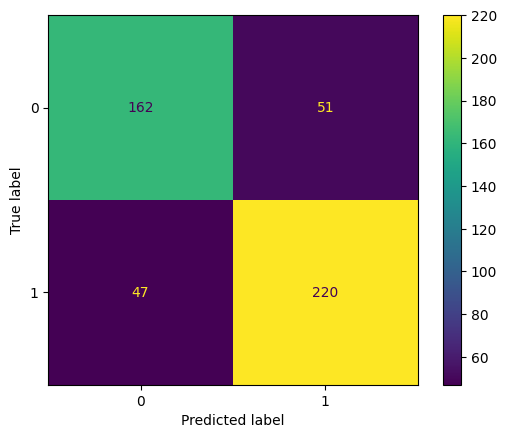

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = best_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()


**Feature Importance Analysis**

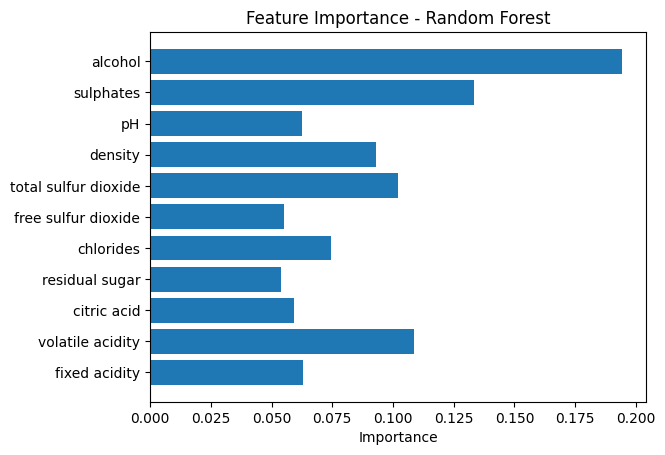

In [ ]:
import numpy as np

importances = best_rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.show()


In [ ]:
sample = X_test[0].reshape(1, -1)
prediction = best_rf.predict(sample)

print("Prediction:", "Good" if prediction[0] == 1 else "Bad")


Prediction: Bad


**Bouns**

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier(random_state=42)

In [ ]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt"]
}

In [ ]:
grid_et = GridSearchCV(
    et,
    param_grid=param_grid,
    cv=5,

)


In [ ]:
grid_et.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=ExtraTreesClassifier(random_state=42),
             param_grid={'max_depth': [None, 20], 'max_features': ['sqrt'],
                         'min_samples_split': [2, 5],
                         'n_estimators': [200, 400]})

In [ ]:
best_et = grid_et.best_estimator_
print("Best Params:", grid_et.best_params_)


Best Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
y_pred = best_et.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))


Accuracy : 0.8104166666666667
Precision: 0.825925925925926
Recall   : 0.8352059925093633


In [ ]:
models_n = {
    "Logistic Regression": best_lr,
    "Perceptron": best_per,
    "Decision Tree": best_dt,
    "SVM": best_svm,
    "Random Forest": best_rf,
    "Extra Trees": best_et
}

In [ ]:
results = []

for name, model in models_n.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-score
5,Extra Trees,0.810417,0.825926,0.835206,0.830540
4,Random Forest,0.795833,0.816479,0.816479,0.816479
3,SVM,0.747917,0.796748,0.734082,0.764133
2,Decision Tree,0.745833,0.775665,0.764045,0.769811
1,Perceptron,0.729167,0.777328,0.719101,0.747082
0,Logistic Regression,0.722917,0.770161,0.715356,0.741748


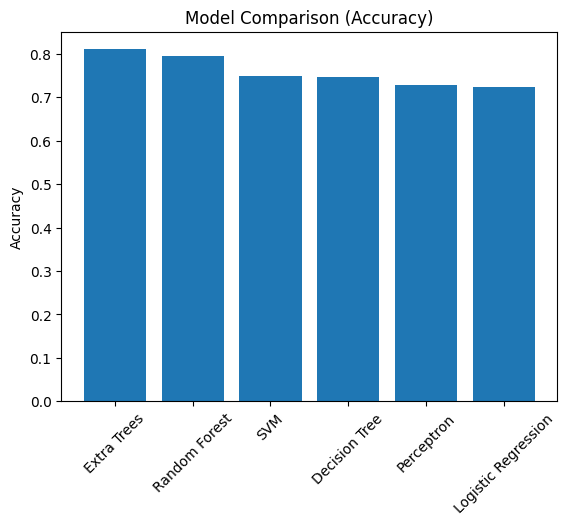

In [ ]:

plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Comparison (Accuracy)")

plt.show()
